# Apple vs Microsoft: Which Stock Shows a Better Balance Between Return and Risk?

## Problem Definition
This project compares Apple (AAPL) and Microsoft (MSFT) to examine which stock shows a more balanced performance between return and risk.

## Target User
The intended users are beginner investors and students who are interested in financial markets and want a simple comparison of two major technology stocks.

## Data Source
This project uses historical stock data retrieved from WRDS.

## Analytical Goal
The analysis focuses on:
- daily returns
- annualised return
- annualised volatility
- maximum drawdown
- return-risk ratio

In [1]:
# If needed, install packages first
# !pip install wrds pandas numpy matplotlib

In [30]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Connect to WRDS

This step connects Python to the WRDS database.

In [52]:
db = wrds.Connection()

Enter your WRDS username [user]: jiayiwu2403
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\user\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## Step 2: Retrieve Data from WRDS

This query aims to collect stock return and price data for Apple and Microsoft between 2021 and 2025.

**Important note:**  
The WRDS library name, table name, and variable names may differ depending on database access.  
They must be checked and adjusted before running the notebook.

In [53]:
print("Problem: Analyze stock return and risk using WRDS CRSP data")

Problem: Analyze stock return and risk using WRDS CRSP data


In [57]:
# Step 2: Retrieve data from WRDS

query = """
SELECT 
    date, 
    permno, 
    ret 
FROM crsp.msf 
WHERE permno IN (14593, 10107)  -- 14593=AAPL, 10107=MSFT
AND date BETWEEN '2020-01-01' AND '2024-12-31'
AND ret IS NOT NULL
ORDER BY date, permno;
"""
print(data.head())

         date  permno       ret        prc
0  2024-01-31   10107  0.057281  397.57999
1  2024-02-29   10107  0.042281  413.64001
2  2024-03-28   10107  0.017116     420.72
3  2024-04-30   10107  -0.07461  389.32999
4  2024-05-31   10107  0.068194     415.13


## Step 3: Inspect the Raw Data

Before analysis, the raw dataset should be checked for structure, missing values, and possible formatting issues.

In [61]:
# Step 3: Inspect the raw data
if 'data' in globals() and isinstance(data, pd.DataFrame):
    print("DataFrame loaded successfully.")
    print("Shape:", data.shape)
    print("Columns:", data.columns.tolist())
    print("\nDataFrame Info:")
    data.info()
    print("\nFirst 5 rows of data:")
    display(data.head())
else:
    print("Error: data is not defined.")
    print("This means Step 2 did not successfully create the DataFrame.")
    print("Please go back and check your WRDS query, table name, field names, and connection.")

DataFrame loaded successfully.
Shape: (24, 4)
Columns: ['date', 'permno', 'ret', 'prc']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    24 non-null     string 
 1   permno  24 non-null     Int64  
 2   ret     24 non-null     Float64
 3   prc     24 non-null     Float64
dtypes: Float64(2), Int64(1), string(1)
memory usage: 972.0 bytes

First 5 rows of data:


,date,permno,ret,prc
0,2024-01-31,10107,0.057281,397.57999
1,2024-02-29,10107,0.042281,413.64001
2,2024-03-28,10107,0.017116,420.72
3,2024-04-30,10107,-0.07461,389.32999
4,2024-05-31,10107,0.068194,415.13


In [62]:
data.head(10)

,date,permno,ret,prc
0,2024-01-31,10107,0.057281,397.57999
1,2024-02-29,10107,0.042281,413.64001
2,2024-03-28,10107,0.017116,420.72
3,2024-04-30,10107,-0.07461,389.32999
4,2024-05-31,10107,0.068194,415.13
5,2024-06-28,10107,0.076651,446.95001
6,2024-07-31,10107,-0.063989,418.35001
7,2024-08-30,10107,-0.0011,417.14001
8,2024-09-30,10107,0.031548,430.29999
9,2024-10-31,10107,-0.055659,406.35001


## Step 4: Clean and Prepare the Data

This step standardises column names, converts numeric variables, removes missing values, and fixes price sign issues if necessary.

In [63]:
# 1. Make a copy of the raw data (avoids modifying the original dataset)
df = data.copy()

# 2. Standardise column names (convert all to lowercase)
df.columns = [col.lower() for col in df.columns]

# 3. Keep only the relevant columns (adjust based on your actual columns)
# If you don't have 'ticker' yet, we'll add it after cleaning
df = df[['date', 'permno', 'ret', 'prc']]

# 4. Convert variables to numeric format (handle any non-numeric values)
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df['prc'] = pd.to_numeric(df['prc'], errors='coerce')

# 5. Drop rows with missing essential values
df = df.dropna(subset=['date', 'permno', 'ret'])

# 6. Fix price sign issues (WRDS prc may be negative for database reasons)
df['prc'] = df['prc'].abs()

# 7. Optional: Map permno to ticker (add this if you want 'ticker' column)
permno_to_ticker = {
    14593: 'AAPL',
    10107: 'MSFT'
}
df['ticker'] = df['permno'].map(permno_to_ticker)

# Preview the cleaned data
print("Cleaned Data Preview:")
print(df.head())

Cleaned Data Preview:
         date  permno       ret        prc ticker
0  2024-01-31   10107  0.057281  397.57999   MSFT
1  2024-02-29   10107  0.042281  413.64001   MSFT
2  2024-03-28   10107  0.017116     420.72   MSFT
3  2024-04-30   10107  -0.07461  389.32999   MSFT
4  2024-05-31   10107  0.068194     415.13   MSFT


In [65]:
data.isnull().sum()

date      0
permno    0
ret       0
prc       0
dtype: int64

## Step 5: Calculate Return and Risk Metrics

To compare the two stocks, this notebook calculates:
- mean daily return
- daily volatility
- annualised return
- annualised volatility
- return-risk ratio

In [68]:
import numpy as np

# 1. Calculate summary statistics grouped by ticker
summary = (
    df.groupby('ticker')['ret']
    .agg(
        mean_monthly_return='mean',
        monthly_volatility='std',
        trading_months='count'
    )
    .reset_index()
)

# 2. Annualise metrics (for monthly data: multiply by 12, volatility multiply by sqrt(12))
summary['annual_return'] = summary['mean_monthly_return'] * 12
summary['annual_volatility'] = summary['monthly_volatility'] * np.sqrt(12)

# 3. Calculate return-risk ratio (Sharpe ratio proxy)
summary['return_risk_ratio'] = summary['annual_return'] / summary['annual_volatility']

# 4. Display the results
print("Return and Risk Metrics Summary:")
print(summary)

Return and Risk Metrics Summary:
  ticker  mean_monthly_return  monthly_volatility  trading_months  \
0   AAPL             0.023962            0.056348              12   
1   MSFT             0.011436            0.052262              12   

   annual_return  annual_volatility  return_risk_ratio  
0       0.287549           0.195196           1.473132  
1       0.137233           0.181041           0.758024  


## Step 6: Calculate Maximum Drawdown

Maximum drawdown is used to measure the largest peak-to-trough loss during the sample period.
A lower drawdown usually means lower downside risk.

In [75]:
def max_drawdown(group):
    # Sort data by date to ensure chronological order
    group = group.sort_values('date').copy()
    # Calculate cumulative return index (1 + ret)
    group['cum_return'] = (1 + group['ret']).cumprod()
    # Calculate running maximum of cumulative returns (peak value)
    group['running_max'] = group['cum_return'].cummax()
    # Calculate drawdown (peak to trough loss)
    group['drawdown'] = (group['cum_return'] - group['running_max']) / group['running_max']
    # Return the minimum drawdown (most negative value)
    return group['drawdown'].min()

mdd = df.groupby('ticker').apply(
    lambda x: max_drawdown(x.drop('ticker', axis=1))
).reset_index(name='max_drawdown')

print("Maximum Drawdown Results:")
print(mdd)

# Merge drawdown into summary table
summary = summary.merge(mdd, on='ticker', how='left')
summary = summary.sort_values(by='return_risk_ratio', ascending=False)

print("\nFull Return & Risk Summary (with Max Drawdown):")
print(summary)

Maximum Drawdown Results:
  ticker  max_drawdown
0   AAPL     -0.075074
1   MSFT     -0.089204

Full Return & Risk Summary (with Max Drawdown):
  ticker  mean_monthly_return  monthly_volatility  trading_months  \
0   AAPL             0.023962            0.056348              12   
1   MSFT             0.011436            0.052262              12   

   annual_return  annual_volatility  return_risk_ratio  max_drawdown_x  \
0       0.287549           0.195196           1.473132       -0.075074   
1       0.137233           0.181041           0.758024       -0.089204   

   max_drawdown_y  max_drawdown  
0       -0.075074     -0.075074  
1       -0.089204     -0.089204  


C:\Users\user\AppData\Local\Temp\ipykernel_4628\4088065050.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mdd = df.groupby('ticker').apply(


## Step 7: Interpret the Summary Table

A stock with:
- higher annual return
- lower annual volatility
- higher return-risk ratio
- smaller maximum drawdown

can be considered more balanced between return and risk.

In [76]:
best_stock = summary.iloc[0]['ticker']

print("Summary of stock performance:")
print(summary)

print(f"\nConclusion: {best_stock} appears to offer the more balanced performance between return and risk based on the return-risk ratio.")

Summary of stock performance:
  ticker  mean_monthly_return  monthly_volatility  trading_months  \
0   AAPL             0.023962            0.056348              12   
1   MSFT             0.011436            0.052262              12   

   annual_return  annual_volatility  return_risk_ratio  max_drawdown_x  \
0       0.287549           0.195196           1.473132       -0.075074   
1       0.137233           0.181041           0.758024       -0.089204   

   max_drawdown_y  max_drawdown  
0       -0.075074     -0.075074  
1       -0.089204     -0.089204  

Conclusion: AAPL appears to offer the more balanced performance between return and risk based on the return-risk ratio.


## Step 8: Visualise Cumulative Returns

This chart shows how one unit of investment grows over time for each stock.

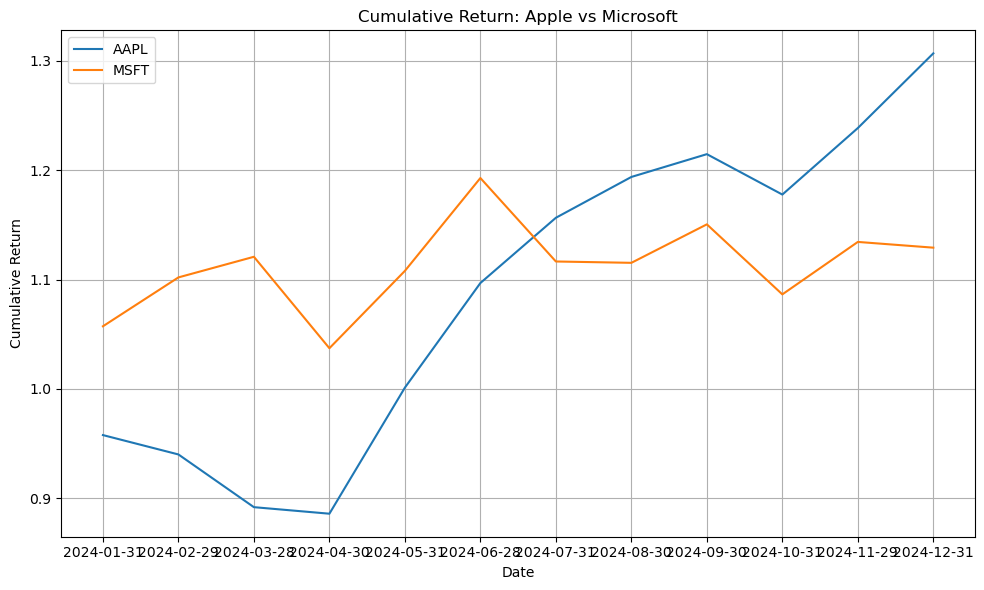

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'df' is the cleaned DataFrame from Step 4
plot_df = df.sort_values(['ticker', 'date']).copy()

# Calculate cumulative returns for each stock
plot_df['cum_return'] = plot_df.groupby('ticker')['ret'].transform(lambda x: (1 + x).cumprod())

# Create the plot
plt.figure(figsize=(10, 6))

# Plot cumulative returns for each stock
for ticker in plot_df['ticker'].unique():
    temp = plot_df[plot_df['ticker'] == ticker]
    plt.plot(temp['date'], temp['cum_return'], label=ticker)

# Add plot labels and formatting
plt.title('Cumulative Return: Apple vs Microsoft')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

## Step 9: Compare Key Return and Risk Indicators

The following bar charts compare annual return, annual volatility, and return-risk ratio.

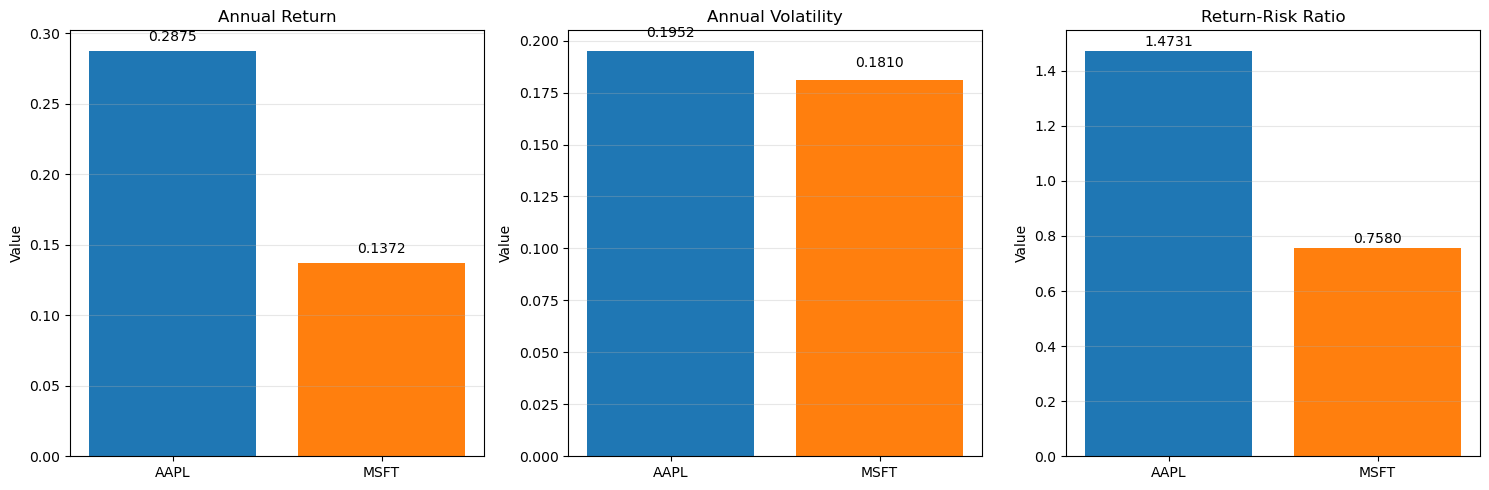

In [78]:
import matplotlib.pyplot as plt

# Create 1x3 subplots for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Annual Return
axes[0].bar(summary['ticker'], summary['annual_return'], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Annual Return', fontsize=12)
axes[0].set_ylabel('Value', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Annual Volatility
axes[1].bar(summary['ticker'], summary['annual_volatility'], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Annual Volatility', fontsize=12)
axes[1].set_ylabel('Value', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Return-Risk Ratio
axes[2].bar(summary['ticker'], summary['return_risk_ratio'], color=['#1f77b4', '#ff7f0e'])
axes[2].set_title('Return-Risk Ratio', fontsize=12)
axes[2].set_ylabel('Value', fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

# Add value labels on top of each bar for readability
for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=10
        )

# Adjust layout and show plot
plt.tight_layout()
plt.show()

## Step 10: Export Results

This step saves the summary table so it can be included in the GitHub repository.

In [79]:
# This step saves the summary table so it can be included in the GitHub repository.
summary.to_csv('apple_microsoft_risk_return_summary.csv', index=False)
print("Summary file saved successfully.")

# Optional: Close WRDS database connection (if you opened it earlier)
if 'db' in globals():
    db.close()

Summary file saved successfully.


## Final Conclusion

This notebook compares Apple and Microsoft from a return-risk perspective using historical stock data from WRDS.

The main indicators include:
- annualised return
- annualised volatility
- return-risk ratio
- maximum drawdown

Based on these metrics, the stock with the higher return-risk ratio and more stable downside profile can be interpreted as the more balanced stock for beginner investors.